In [1]:
import pickle
from matplotlib import pyplot as plt
import numpy as np

In [2]:
with open('../data/consolitdation.pkl', 'rb') as f:
    consolidation = pickle.load(f)

with open('../data/remapping.pkl', 'rb') as f:
    remapping = pickle.load(f)

    

In [3]:
place_field_shift_consolidation = np.argmax(consolidation[0]['rate_avg'], axis=0) - np.argmax(consolidation[1]['rate_avg'], axis=0)
place_field_shift_remapping = np.argmax(remapping[0]['rate_avg'], axis=0) - np.argmax(remapping[1]['rate_avg'], axis=0)

steps = 500

v_data_place_filed_shifts = np.vstack([place_field_shift_consolidation, place_field_shift_remapping])
m1 = v_data_place_filed_shifts >= steps // 2
v_data_place_filed_shifts[m1] -= steps
m2 = v_data_place_filed_shifts <= -steps // 2
v_data_place_filed_shifts[m2] += steps

v_data_amp = np.vstack([consolidation[0]['rate_avg'].max(axis=0), consolidation[1]['rate_avg'].max(axis=0), remapping[1]['rate_avg'].max(axis=0)])

In [4]:
mosaic = """
    AABBCC
    DDDEEE
    FFFGGG
    """

place_filed_tiles = ['A', 'B', 'C']
titles = ['Mapping', 'Consolidation', 'Remapping']



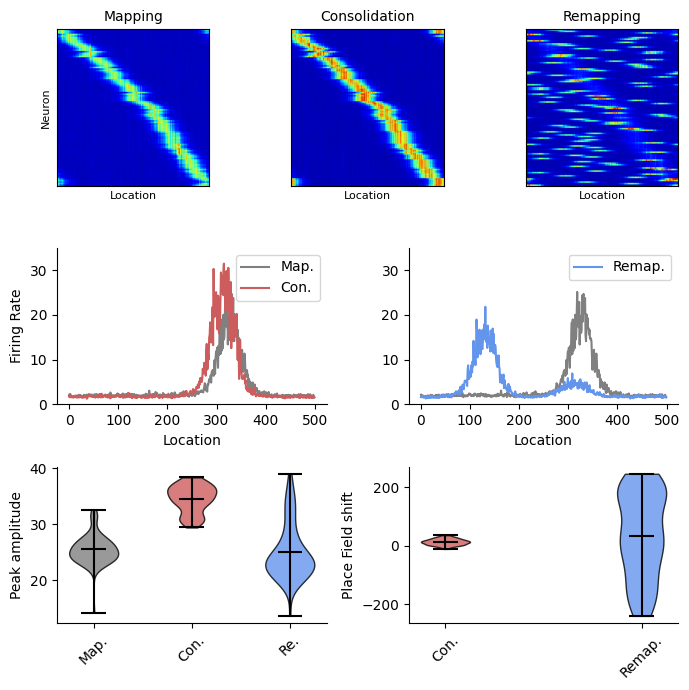

In [5]:
#fig = plt.figure(layout="constrained")
fig = plt.figure(figsize=(7,7))

ax_dict = fig.subplot_mosaic(mosaic)

vmin = 0
vmax = 35
cmap = 'jet'

neuron_id = 51

ax_dict['A'].imshow(consolidation[0]['rate_avg'].T[consolidation[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
ax_dict['B'].imshow(consolidation[1]['rate_avg'].T[consolidation[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
#ax_dict['B'].imshow(remapping[0]['rate_avg'].T[remapping[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap)
ax_dict['C'].imshow(remapping[1]['rate_avg'].T[remapping[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')


for tile in place_filed_tiles:

    ax_dict[tile].set_xticks([])
    ax_dict[tile].set_yticks([])

    ax_dict[tile].set_xlabel('Location', fontsize=8)

ax_dict['A'].set_ylabel('Neuron', fontsize=8)

for (tile, title) in zip(place_filed_tiles, titles):
    ax_dict[tile].set_title(title, fontsize=10)

ax_dict['A'].set_ylabel('Neuron')


ax_dict['D'].plot(consolidation[0]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='grey', label='Map.')
ax_dict['D'].plot(consolidation[1]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='indianred', label='Con.')
ax_dict['D'].set_xlabel('Location')
ax_dict['D'].set_ylabel('Firing Rate')
ax_dict['D'].set_ylim([0, 35])

ax_dict['D'].spines['top'].set_visible(False)
ax_dict['D'].spines['right'].set_visible(False)
ax_dict['D'].legend()


ax_dict['E'].plot(remapping[0]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='grey')
ax_dict['E'].plot(remapping[1]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='cornflowerblue', label='Remap.')
ax_dict['E'].set_xlabel('Location')
ax_dict['E'].set_ylim([0, 35])

ax_dict['E'].spines['top'].set_visible(False)
ax_dict['E'].spines['right'].set_visible(False)
ax_dict['E'].legend()

amp_vio_plot = ax_dict['F'].violinplot(v_data_amp.T, positions=[1, 2, 3], showmeans=True)
ax_dict['F'].set_ylabel('Peak amplitude')
ax_dict['F'].set_xticks([1, 2, 3])
ax_dict['F'].set_xticklabels(['Map.', 'Con.', 'Re.'], rotation=45)

amp_vio_plot_colors = ['grey', 'indianred', 'cornflowerblue']

amp_vio_plot['cbars'].set_color('k')
amp_vio_plot['cmeans'].set_color('k')
amp_vio_plot['cmins'].set_color('k')
amp_vio_plot['cmaxes'].set_color('k')

for i, pc in enumerate(amp_vio_plot['bodies']):
    pc.set_facecolor(amp_vio_plot_colors[i])
    pc.set_edgecolors('k')
    pc.set_alpha(0.8)
    
ax_dict['F'].spines['top'].set_visible(False)
ax_dict['F'].spines['right'].set_visible(False)
    
shift_vio_plot_colors = ['indianred', 'cornflowerblue']

shift_vio_plot = ax_dict['G'].violinplot(v_data_place_filed_shifts.T, positions=[1, 3], showmeans=True)
ax_dict['G'].set_ylabel('Place Field shift')
ax_dict['G'].set_xticks([1, 3])
ax_dict['G'].set_xticklabels(['Con.', 'Remap.'], rotation=45)

shift_vio_plot['cbars'].set_color('k')
shift_vio_plot['cmeans'].set_color('k')
shift_vio_plot['cmins'].set_color('k')
shift_vio_plot['cmaxes'].set_color('k')

for i, pc in enumerate(shift_vio_plot['bodies']):
    pc.set_facecolor(shift_vio_plot_colors[i])
    pc.set_edgecolors('k')
    pc.set_alpha(0.8)
    
ax_dict['G'].spines['top'].set_visible(False)
ax_dict['G'].spines['right'].set_visible(False)


plt.tight_layout()

plt.savefig('fig2.png')

In [6]:
remapping[0]['rate_avg'].T[consolidation[0]['sorting']][0].shape

(500,)

In [9]:
np.sort(consolidation[0]['f'].max(axis=1))


array([0.5899149 , 0.67858824, 0.68691664, 0.68701142, 0.6960325 ,
       0.69956772, 0.70400664, 0.70908924, 0.71010729, 0.71195294,
       0.7174021 , 0.71896293, 0.72474974, 0.72734733, 0.72838786,
       0.7289249 , 0.72932495, 0.72939583, 0.73068333, 0.73114953,
       0.73165748, 0.7330911 , 0.73905198, 0.73980214, 0.73982304,
       0.74079445, 0.74092897, 0.74151614, 0.74345852, 0.74503925,
       0.7456864 , 0.7469243 , 0.74776311, 0.74822539, 0.74873205,
       0.74962261, 0.74992774, 0.75046285, 0.75414722, 0.75448161,
       0.75646695, 0.75914858, 0.75955014, 0.7608971 , 0.76210039,
       0.76375608, 0.7665858 , 0.76732799, 0.76807375, 0.76951451,
       0.77221824, 0.77411967, 0.775221  , 0.77743366, 0.77744824,
       0.77903666, 0.78096846, 0.78380259, 0.78485499, 0.78603283,
       0.78671375, 0.78671674, 0.7867501 , 0.788834  , 0.79016927,
       0.79045038, 0.79064912, 0.79462507, 0.79555476, 0.7978976 ,
       0.79960854, 0.80003599, 0.80075836, 0.80344251, 0.80705